<h1><center>Import necessary libraries and data</center></h1>

In [51]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# set params for anlysis.
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize']=(5,5)

np.set_printoptions(legacy='1.25')

In [41]:
# Import data
cc_df= pd.read_csv('/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/AIML Dataset.csv')

In [42]:
# View the first five rows to ensure data loaded properly.
cc_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


<h1><center>EDA/Transformations</center></h1>

In [44]:
# View dataset info.
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
# Display columns.
cc_df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [46]:
# Value count for is fraud column.
cc_df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [47]:
# Value count for is flagged fraud column.
cc_df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
# Check for null values.
cc_df.isnull().sum().sum()

0

In [ ]:
# view the shape of the data.
cc_df.shape

(6362620, 11)

In [ ]:
# Calculate the is fraud percentage.
(cc_df['isFraud'].value_counts()[1]/cc_df.shape[0]*100).round(3)

0.129

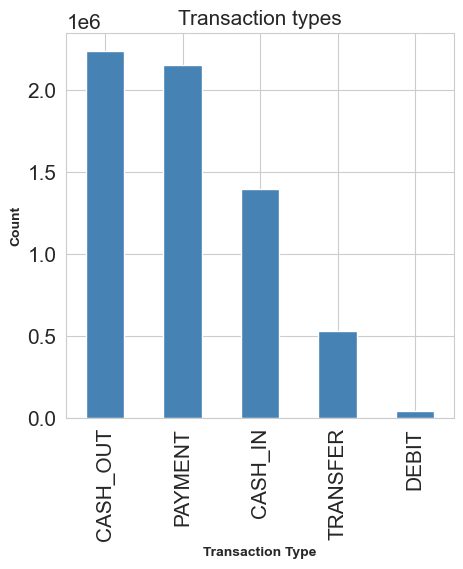

In [ ]:
# Graph transaction types.
cc_df['type'].value_counts().plot(kind='bar', title='Transaction types',
                                  color = 'steelblue')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

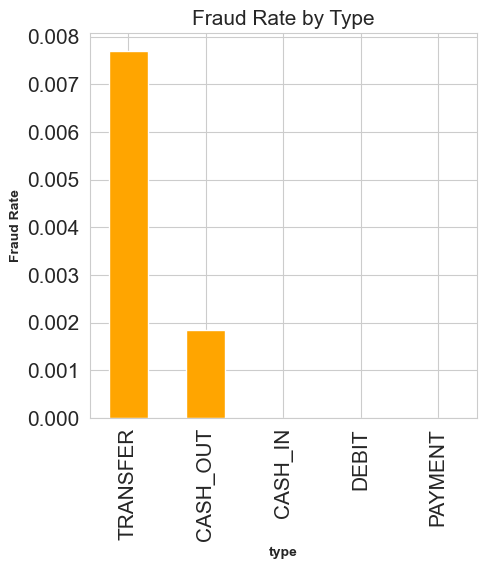

In [64]:
# Graph fraud rate. 
fraud_by_type = cc_df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', title='Fraud Rate by Type', color = 'orange')
plt.ylabel('Fraud Rate')
plt.show()

In [ ]:
# View fraud by type.
fraud_by_type 

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [67]:
# View descriptive statistics for amount column.
cc_df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

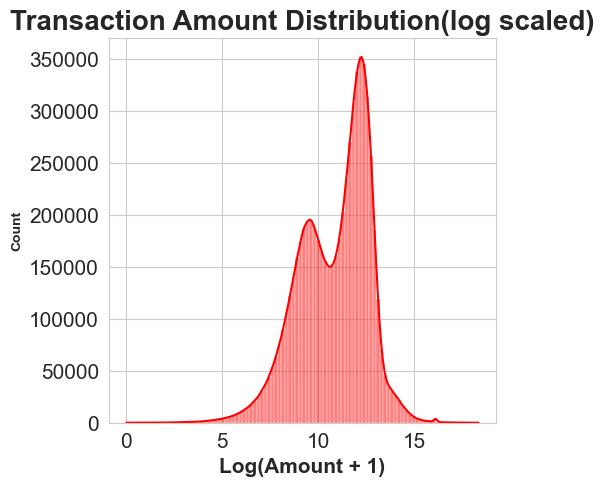

In [ ]:
# Graph log distributrion of amount feature.
sns.histplot(np.log1p(cc_df['amount']), bins=100, kde=True, color = 'red')
plt.title('Transaction Amount Distribution(log scaled)', fontsize = 20, weight = 'bold')
plt.xlabel('Log(Amount + 1)', fontsize = 15, weight = 'bold')
plt.show()

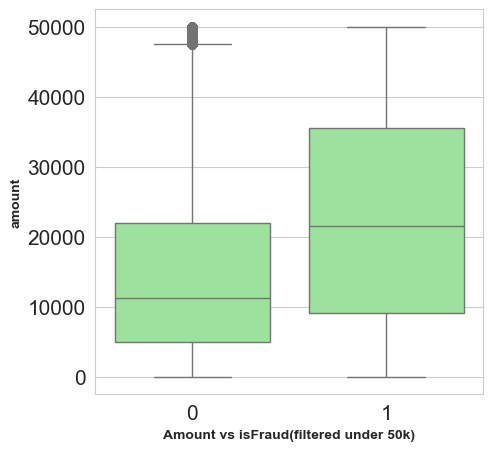

In [ ]:
# Create a box plot comparing the amount and isFraud features.
sns.boxplot(data = cc_df[cc_df['amount']< 50000], x = 'isFraud', y = 'amount', color = 'lightgreen')
plt.xlabel('Amount vs isFraud(filtered under 50k)')
plt.show()

In [ ]:
# Create new features.
cc_df['balanceDiffOrig'] = cc_df['oldbalanceOrg'] - cc_df['newbalanceOrig']
cc_df['balanceDiffDest'] = cc_df['newbalanceDest'] - cc_df['oldbalanceDest']

In [ ]:
# Checking and suming negative values in balanceDiffOrig feature.
(cc_df['balanceDiffOrig']<0).sum()

1399253

In [ ]:
# Checking and suming negative values in balanceDiffDest feature.
(cc_df['balanceDiffDest']<0).sum()

1238864

In [ ]:
# View the first two rows in dataset.
cc_df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiff Dest,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.0


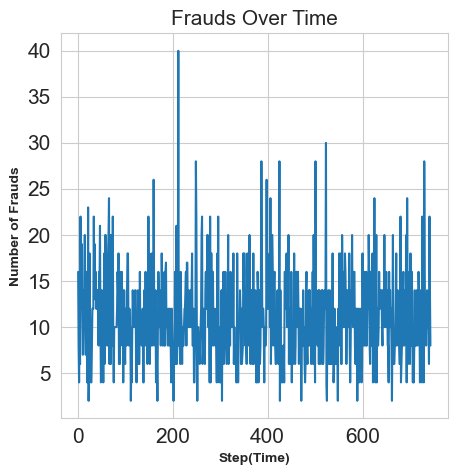

In [ ]:
# Test the step feature for time dependence.
fraud_per_step = cc_df[cc_df['isFraud']==1]['step'].value_counts().sort_index()
plt.plot(fraud_per_step.index, fraud_per_step.values, label ='Frauds Per Step')
plt.xlabel('Step(Time)')
plt.ylabel('Number of Frauds')
plt.title('Frauds Over Time')
plt.grid(True)
plt.show()

In [98]:
cc_df.drop(columns='step', inplace=True)

In [99]:
cc_df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiff Dest,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.0
744,PAYMENT,9805.46,C480184864,0.0,0.00,M1433956626,0.0,0.0,0,0,0.00,0.0,0.0
745,PAYMENT,9470.85,C483525032,0.0,0.00,M2109219177,0.0,0.0,0,0,0.00,0.0,0.0
746,PAYMENT,20560.86,C429058804,0.0,0.00,M259319861,0.0,0.0,0,0,0.00,0.0,0.0
747,PAYMENT,13679.84,C52913970,0.0,0.00,M1059634518,0.0,0.0,0,0,0.00,0.0,0.0


In [ ]:
# Identify and view the top 10 senders.
top_senders = cc_df['nameOrig'].value_counts().head(10)
top_senders

nameOrig
C1902386530    3
C1976208114    3
C724452879     3
C1530544995    3
C363736674     3
C545315117     3
C2051359467    3
C1784010646    3
C2098525306    3
C1677795071    3
Name: count, dtype: int64

In [ ]:
# Identify and view the top 10 receivers.
top_receivers = cc_df['nameDest'].value_counts().head(10)
top_receivers

nameDest
C1286084959    106
C665576141     100
C248609774      97
C2083562754     94
C97730845       94
C977993101      94
C985934102      92
C1899073220     91
C1360767589     90
C1782113663     90
Name: count, dtype: int64

In [ ]:
# View the top 10 fraud users.
fraud_users = cc_df[cc_df['isFraud']==1]['nameOrig'].value_counts().head(10)
fraud_users

nameOrig
C1334405552    1
C531780975     1
C151517061     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
Name: count, dtype: int64

In [ ]:
# Filter  fraud types based on transfer and cash out features.
fraud_types = cc_df[cc_df['type'].isin(['TRANSFER', 'CASH_OUT'])] 
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiff Dest,balanceDiffDest
768,TRANSFER,463722.76,C1734184086,349.00,0.00,C832279283,18285.39,185389.80,0,0,349.00,167104.41,167104.41
769,TRANSFER,138857.19,C1947941827,109473.00,0.00,C1789550256,1027402.57,4619798.56,0,0,109473.00,3592395.99,3592395.99
776,CASH_OUT,88987.11,C2014563089,2816.58,0.00,C932583850,696184.96,2719172.89,0,0,2816.58,2022987.93,2022987.93
781,TRANSFER,345698.98,C1453062635,40419.00,0.00,C997608398,20489.94,157982.12,0,0,40419.00,137492.18,137492.18
789,TRANSFER,32132.45,C2116299597,62491.91,30359.46,C1466073198,59605.00,0.00,0,0,32132.45,-59605.00,-59605.00


In [ ]:
# Count the number of fraud types in cash out and transfer.
fraud_types['type'].value_counts()

type
CASH_OUT    2237350
TRANSFER     532836
Name: count, dtype: int64

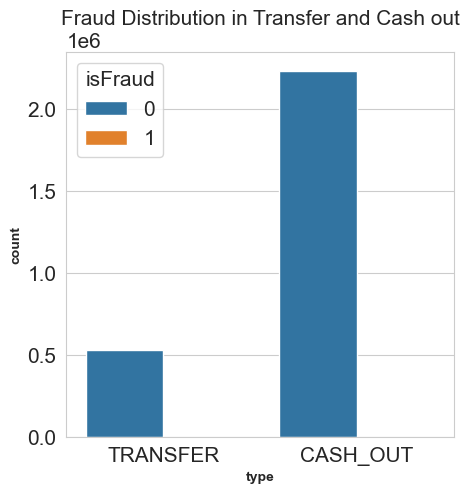

In [ ]:
# Graph the fraud types.
sns.countplot(fraud_types, x = 'type', hue = 'isFraud')
plt.title('Fraud Distribution in Transfer and Cash out')
plt.show()

In [ ]:
# Create a correlation matrix.
corr = cc_df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest",
              "newbalanceDest", "isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002764,-0.007863,0.294133,0.459310,0.076727
oldbalanceOrg,-0.002764,1.000000,0.998803,0.066239,0.042024,0.010168
newbalanceOrig,-0.007863,0.998803,1.000000,0.067807,0.041832,-0.008143
oldbalanceDest,0.294133,0.066239,0.067807,1.000000,0.976589,-0.005879
newbalanceDest,0.459310,0.042024,0.041832,0.976589,1.000000,0.000535
isFraud,0.076727,0.010168,-0.008143,-0.005879,0.000535,1.000000


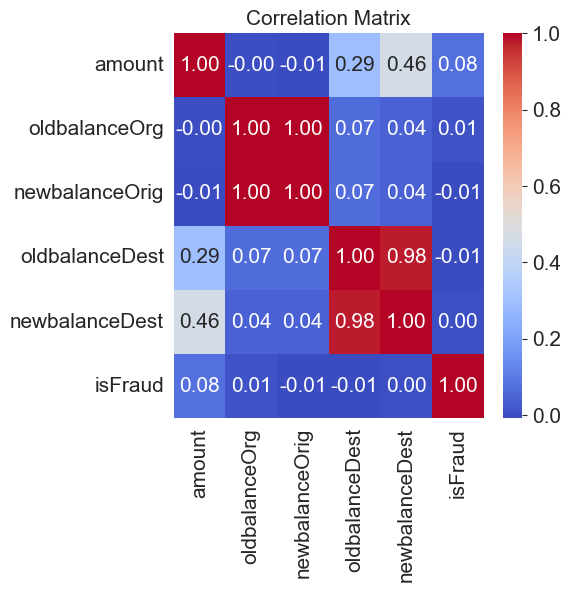

In [ ]:
# Visualize correlation matrix with a heatmap.
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()